In [6]:
%pip install numpy matplotlib imageio pillow networkx

Note: you may need to restart the kernel to use updated packages.


In [ ]:

nodes = ['A', 'P', 'XVIII', 'XI', '4', '5', '6', '7', '9', '11']
destinations = ['4', '5', '6', '7', '9', '11']

adj = {
    'A': ['XVIII'],
    'XVIII': ['5', '6', 'XI'],
    '6': ['7'],
    'P': ['XI'],
    'XI': ['9', '4', '11', 'X'],
    # ...
}
capacities = {
    ('P', 'XI'): 2670.3,
    ('XVIII', 'XI'): 3644.6,
    ('XVIII', '6'): 4878.2,
    # ...
}

requests = {
    ('A', '1'): 738.0
    # ...
}



---

# Оптимизация распределенной электрической сети методом Муравьиной колонии (ACS)

### Описание логики задачи
Данная реализация адаптирует классический муравьиный алгоритм под задачу распределения мощностей в электрической сети «Альфа».

**Основные концепции адаптации:**
1.  **Квантование энергии (Муравьи-киловатты):** Каждая заявка на поставку (например, 738 кВт) разбивается на мелкие порции — **кванты** (по умолчанию 10 кВт). Один муравей в нашей системе — это один такой квант.
2.  **Равнодоступность:** Все муравьи от всех поставщиков перемешиваются в общем пуле (`ants_pool`). Это гарантирует, что при возникновении дефицита мощности на участках, объемы будут ограничиваться пропорционально и честно, так как муравьи конкурируют за «место в проводе» одновременно.
3.  **3D-Феромоны (Навигация по целям):** В отличие от стандартных задач, здесь муравьи имеют разные цели (разных потребителей). Поэтому матрица феромонов имеет три измерения: `[откуда][куда][целевой_потребитель]`. Это позволяет муравьям не путаться в чужих следах и строить маршруты именно к своему потребителю.
4.  **Динамическая эвристика (Свободная мощность):** Вместо расстояния муравьи оценивают **доступную пропускную способность** участка. Если линия начинает «забиваться», её привлекательность для муравьев падает, что заставляет их искать обходные пути еще до того, как лимит будет полностью исчерпан.

---

### Ключевые моменты проделанной работы:
1.  **Защита от перегрузок:** Условие `if free_cap >= quantum` гарантирует, что ни один муравей не нарушит технические ограничения, указанные в Таблице 1.2.
2.  **Интеллектуальный обход:** Благодаря параметру `beta`, муравьи будут «чувствовать» снижение свободной мощности на популярных участках и автоматически выбирать альтернативные пути из словаря `adj`.
3.  **Изоляция потоков:** Использование `pheromones[u][v][target]` позволяет моделировать сложную сеть, где потоки к разным потребителям не мешают друг другу в плане навигации, но конкурируют за физический ресурс — мощность линии.

In [56]:
import numpy as np
import random

def ant_colony_power_flow(nodes, destinations, adj, capacities, requests,
                          quantum=10.0, alpha=1.0, beta=3.0, rho=0.3,
                          Q=100.0, n_iterations=30, tau0=1.0, seed=42):
    """
    Алгоритм Муравьиной Системы (ACS) для балансировки потоков мощности в ориентированной электросети.

    Аргументы:
        nodes: Список всех узлов сети (включая генераторы, транзит и потребителей).
        destinations: Список узлов-потребителей, к которым направляются потоки.
        adj: Словарь ориентированной топологии {узел: [список_соседей, куда можно передать ток]}.
        capacities: Словарь лимитов пропускной способности {(узел_А, узел_Б): мощность_кВт}.
        requests: Словарь заявок на передачу энергии {(источник, потребитель): объем_кВт}.
        quantum: "Вес" одного муравья в кВт (шаг квантования непрерывного потока мощности).
        alpha: Вес накопленного опыта колонии (влияние феромона).
        beta: Вес текущего состояния сети (влияние свободного места на ЛЭП).
        rho: Коэффициент испарения феромона (скорость "забывания" плохих путей).
        Q: Базовая константа для расчета награды за успешно найденный путь.
        n_iterations: Количество циклов поиска (поколений колонии).
        tau0: Начальный базовый уровень феромона на всех участках.
        seed: Зерно генератора случайных чисел для повторяемости результатов.
        
    Возвращает:
        history: Список словарей со статистикой и маршрутами для каждого поколения.
    """
    
    # Инициализация генератора случайных чисел
    rng = np.random.RandomState(seed)
    
    # Для ориентированного графа: если участка нет в словаре capacities, передача по нему невозможна
    DEFAULT_CAP = 0.0 

    # 1. ИНИЦИАЛИЗАЦИЯ 3D МАТРИЦЫ ФЕРОМОНОВ
    # Структура: [Текущий_Узел][Следующий_Узел][Конечный_Потребитель_Заявки]
    # Разделение по конечным потребителям не дает муравьям с разными целями сбивать друг друга с пути
    pheromones = {
        u: {v: {dest: tau0 for dest in destinations} for v in neighbors}
        for u, neighbors in adj.items()
    }

    history = []

    # ==========================================
    # ГЛАВНЫЙ ЦИКЛ ПОКОЛЕНИЙ (ИТЕРАЦИИ ОБУЧЕНИЯ)
    # ==========================================
    for iteration in range(n_iterations):
        
        # current_load хранит количество кВт, уже занятых на каждом участке в текущем поколении
        current_load = {edge: 0.0 for edge in capacities.keys()}
        
        # Хранилище для визуализации: содержит кортежи (сам_путь, узел_старта, узел_цели)
        successful_paths = []

        # 2. ФОРМИРОВАНИЕ ПУЛА МУРАВЬЕВ (Квантование заявок)
        ants_pool = []
        for (src, dst), volume in requests.items():
            # Рассчитываем, сколько муравьев (пакетов по quantum кВт) нужно для этой заявки
            num_ants_for_req = int(volume / quantum)
            for _ in range(num_ants_for_req):
                ants_pool.append((src, dst))

        # Перемешивание пула обеспечивает честную конкуренцию за провода.
        # Муравьи от разных источников будут занимать сеть вперемешку.
        random.seed(seed + iteration)
        random.shuffle(ants_pool)

        # 3. ДВИЖЕНИЕ МУРАВЬЕВ
        for ant in ants_pool:
            current_node, target = ant
            
            # Запоминаем начальную точку для последующей отрисовки графиков
            start_node = current_node 
            
            path = [current_node]
            visited = {current_node} # Множество для защиты от зацикливания (токов КЗ)

            # Муравей движется по графу, пока не достигнет своей цели
            while current_node != target:
                neighbors = adj.get(current_node, [])
                if not neighbors:
                    break # Физический тупик в топологии

                attractions = []
                valid_neighbors = []

                # --- 3.1. ОЦЕНКА ДОСТУПНЫХ ВАРИАНТОВ ПЕРЕХОДА ---
                for v in neighbors:
                    if v in visited:
                        continue # Пропускаем узлы, где муравей уже был в этом рейсе

                    edge = (current_node, v)
                    limit = capacities.get(edge, DEFAULT_CAP)
                    
                    # Проверяем оставшееся физическое место на проводе
                    free_cap = limit - current_load.get(edge, 0.0)

                    # Если квант энергии физически может пройти в этот провод
                    if free_cap >= quantum:
                        # Берем след феромона, оставленный для нашей конкретной цели
                        tau_val = pheromones[current_node][v][target]
                        
                        # ФОРМУЛА ПРИВЛЕКАТЕЛЬНОСТИ (Опыт ^ alpha * Свободное_место ^ beta)
                        # min(free_cap, 10000.0) стабилизирует математику при огромных лимитах
                        attr = (tau_val ** alpha) * (min(free_cap, 10000.0) ** beta)
                        
                        attractions.append(attr)
                        valid_neighbors.append(v)

                # Если нет доступных путей (все забито или тупики) — муравей "погибает"
                if not attractions:
                    break

                # --- 3.2. ВЫБОР СЛЕДУЮЩЕГО УЗЛА (Метод рулетки) ---
                sum_attr = sum(attractions)
                if sum_attr == 0.0:
                    break # Защита от деления на ноль
                
                # Вычисляем вероятности перехода: чем выше привлекательность, тем больше шанс
                probs = [attr / sum_attr for attr in attractions]
                
                # Взвешенный случайный выбор узла (Баланс Exploitation и Exploration)
                next_node = rng.choice(valid_neighbors, p=probs)

                # --- 3.3. ОБНОВЛЕНИЕ СОСТОЯНИЯ (Динамическая балансировка) ---
                actual_edge = (current_node, next_node)
                
                # Занимаем мощность на выбранном участке. 
                # Следующий муравей в этой итерации увидит здесь меньше свободного места.
                current_load[actual_edge] = current_load.get(actual_edge, 0.0) + quantum
                
                # Шаг муравья
                path.append(next_node)
                visited.add(next_node)
                current_node = next_node

            # Если муравей успешно дошел до цели, сохраняем его маршрутные данные
            if current_node == target:
                successful_paths.append((path, start_node, target))

        # ==========================================
        # 4. ОБНОВЛЕНИЕ ФЕРОМОНОВ (ГЛОБАЛЬНОЕ)
        # ==========================================
        
        # 4.1. ИСПАРЕНИЕ (Evaporation)
        # Колония "забывает" старые, забитые или неэффективные пути
        for u in pheromones:
            for v in pheromones[u]:
                for dest in pheromones[u][v]:
                    pheromones[u][v][dest] *= (1.0 - rho)
                    # Жесткий лимит снизу, чтобы вероятность выбора пути никогда не падала до 0
                    pheromones[u][v][dest] = max(pheromones[u][v][dest], 0.0001)

        # 4.2. ОТЛОЖЕНИЕ ФЕРОМОНА (Поощрение успешных маршрутов)
        # (Символ _ используется для пропуска переменной start_node, она здесь не нужна)
        for path, _, target in successful_paths:
            path_length = len(path) - 1
            
            for i in range(path_length):
                u, v = path[i], path[i+1]
                
                # Получаем физический лимит конкретного участка ЛЭП
                edge_capacity = capacities.get((u, v), 0.0)

                # ФОРМУЛА НАГРАДЫ (С учетом физики сети):
                # 1. (Q / path_length) - штрафует длинные маршруты (минимизация потерь при передаче)
                # 2. (edge_capacity / quantum) - сильно поощряет использование "толстых" магистральных ЛЭП
                delta_tau = (Q / path_length) * (edge_capacity / quantum)
                
                # Наносим феромон на участок
                pheromones[u][v][target] += delta_tau

        # 5. СОХРАНЕНИЕ ИСТОРИИ (Для визуализации и аналитики)
        history.append({
            'iteration': iteration + 1,
            'load_distribution': current_load.copy(),
            'successful_paths': successful_paths
        })

    return history



---

# Тестовые данные

Запуск алгоритма муравьиной колонии...


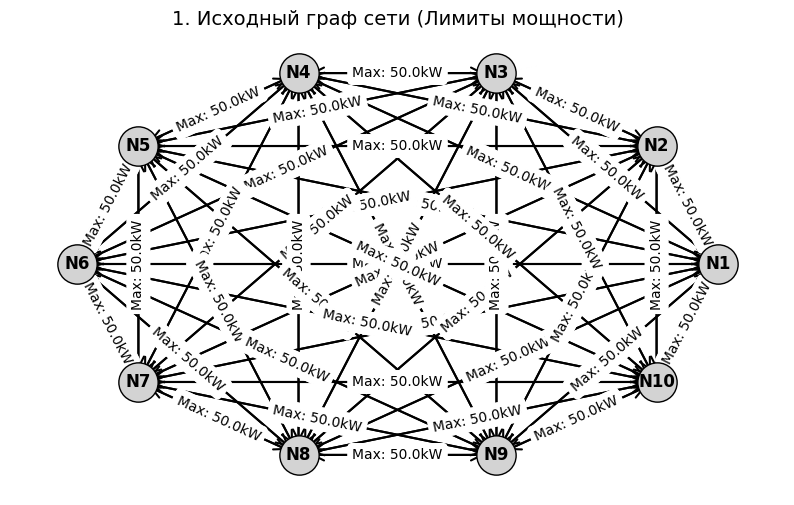

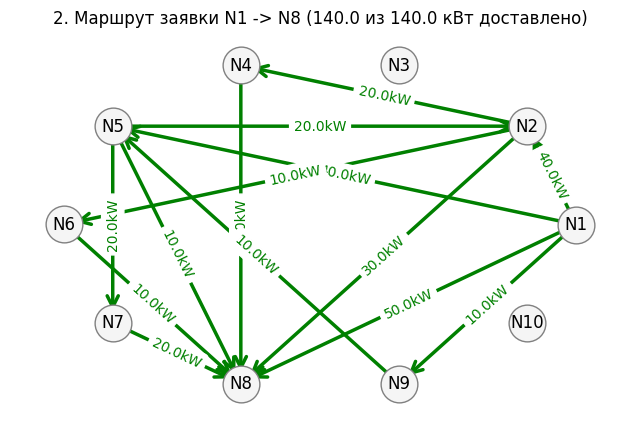

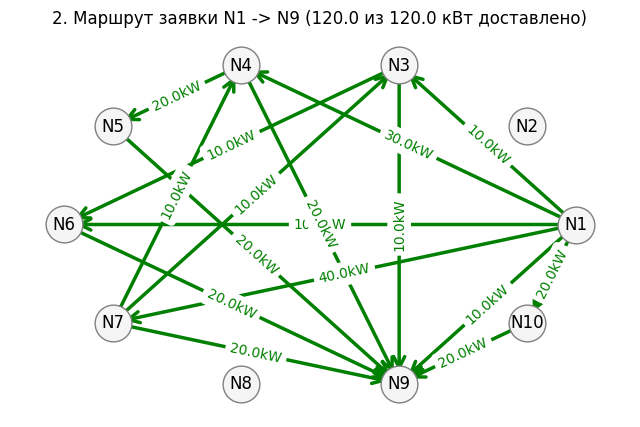

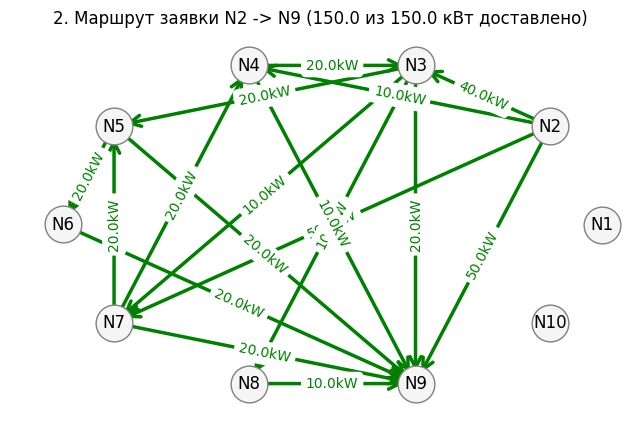

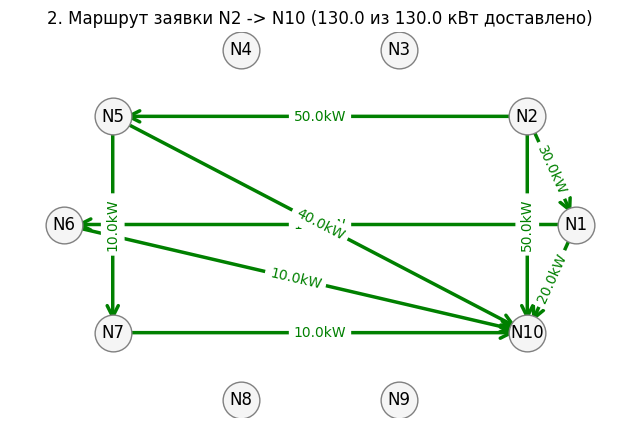

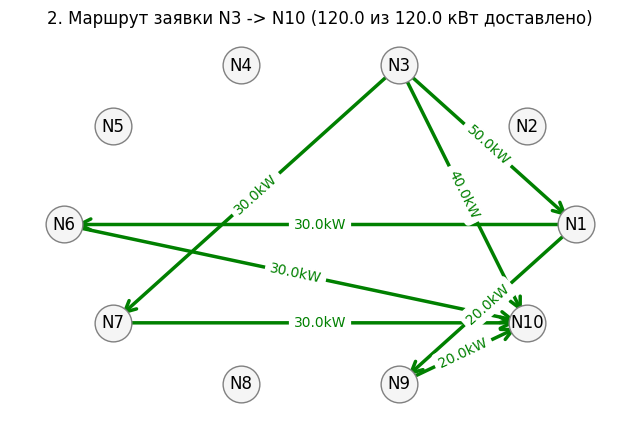

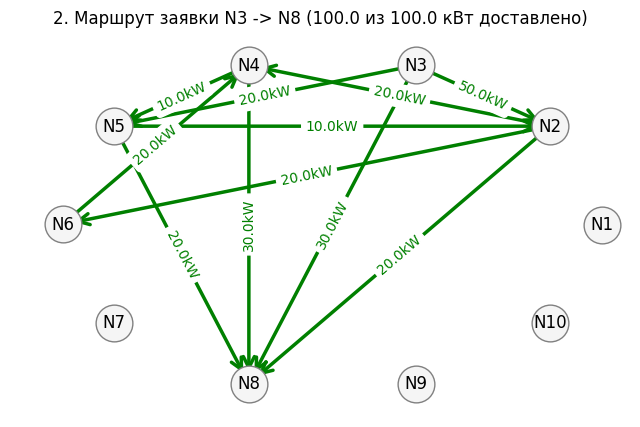

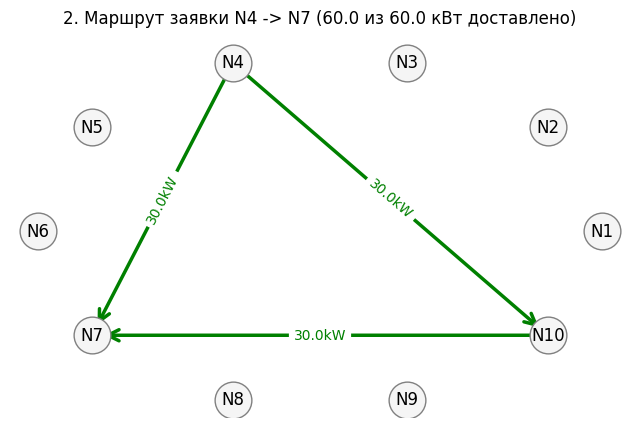

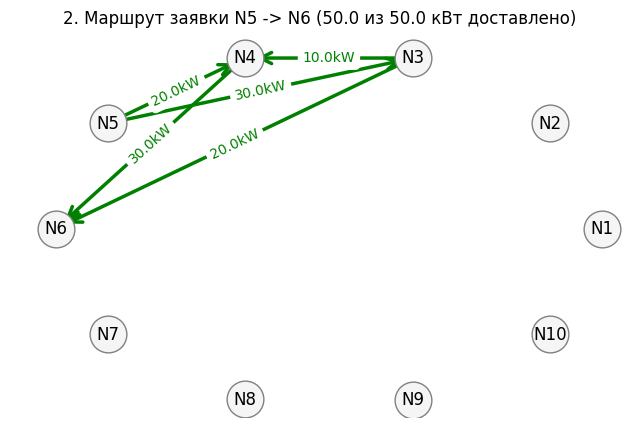

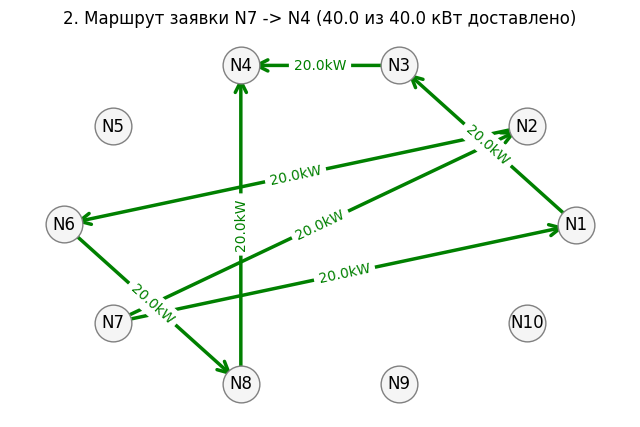

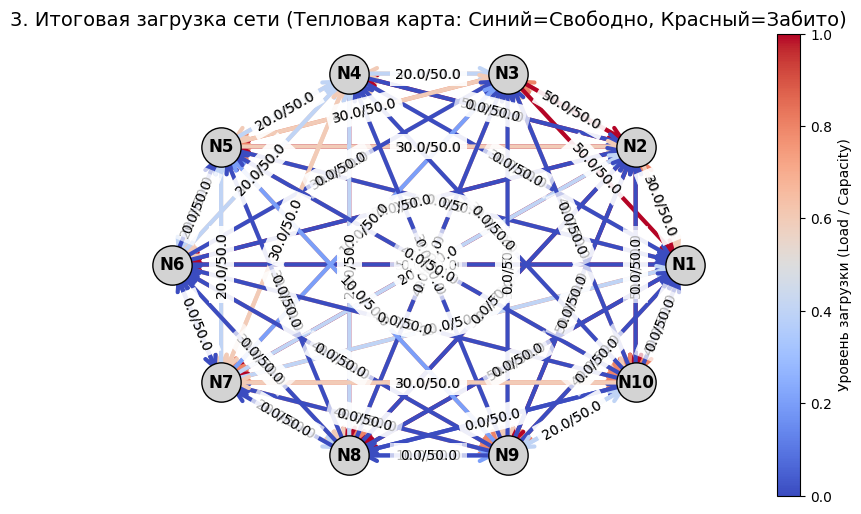

Обучение завершено. Доставлено 910.0 кВт из 910.0 кВт.


In [60]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import math

# ==========================================
# 1. ГЕНЕРАЦИЯ ТЕСТОВЫХ ДАННЫХ
# ==========================================

# Узлы графа (10 штук: N1 - N10)
nodes = [f'N{i}' for i in range(1, 11)]

# Роли узлов (для понимания топологии)
sources = ['N1', 'N2', 'N3']
transit = ['N4', 'N5', 'N6', 'N7']

# Создаем полносвязную топологию (каждый узел связан со всеми остальными)
adj = {u: [v for v in nodes if v != u] for u in nodes}

random.seed(777) 

# Задаем жесткий лимит пропускной способности для всех линий: 50.0 кВт
capacities = {}
for u in nodes:
    for v in nodes:
        if u != v:
            capacities[(u, v)] = 50.0

# Экстремальная загрузка сети: суммарно нужно передать 910 кВт.
# Так как лимит любой линии 50 кВт, алгоритму придется активно дробить 
# заявки и искать сложные транзитные обходные пути.
requests = {
    ('N1', 'N8'): 140.0,
    ('N1', 'N9'): 120.0,
    ('N2', 'N9'): 150.0,
    ('N2', 'N10'): 130.0,
    ('N3', 'N10'): 120.0,
    ('N3', 'N8'): 100.0,
    ('N4', 'N7'): 60.0,   # Фоновый трафик между транзитными узлами
    ('N5', 'N6'): 50.0,
    ('N7', 'N4'): 40.0
}

# Автоматическое извлечение всех узлов-потребителей из словаря заявок
destinations = list(set(dst for src, dst in requests.keys()))


# ==========================================
# 2. ФУНКЦИИ ВИЗУАЛИЗАЦИИ
# ==========================================

def draw_base_graph(G, pos, edge_labels, title):
    """
    Вспомогательная функция для базовой отрисовки топологии сети.
    
    Аргументы:
        G: Объект графа NetworkX.
        pos: Словарь координат узлов для отрисовки {узел: (x, y)}.
        edge_labels: Подписи для ребер (например, лимиты мощности).
        title: Заголовок графика.
    """
    plt.figure(figsize=(10, 6))
    plt.title(title, fontsize=14)
    
    # Отрисовка узлов
    nx.draw_networkx_nodes(G, pos, node_color='lightgray', node_size=800, edgecolors='black')
    nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')
    
    # Отрисовка стрелок (ребер)
    nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20, edge_color='black', width=1.5)
    
    # Отрисовка подписей на ребрах
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10, font_color='black')
    
    plt.axis('off') # Отключаем оси координат для красоты
    plt.show()


def visualize_results(nodes, adj, capacities, requests, history, quantum):
    """
    Главная функция визуализации. Строит 3 типа графиков:
    1. Исходная топология сети с лимитами.
    2. Индивидуальные маршруты для каждой заявки (зеленые стрелки).
    3. Итоговая тепловая карта загруженности сети (от синего к красному).
    """
    
    # --- 1. Подготовка графа и координат ---
    G = nx.DiGraph()
    for u in adj:
        for v in adj[u]:
            G.add_edge(u, v, capacity=capacities.get((u,v), 0))

    # Расставляем 10 узлов по кругу (правильный многоугольник) с помощью тригонометрии
    pos = {}
    for i, node in enumerate(nodes):
        angle = 2 * math.pi * i / len(nodes)
        # Радиус окружности = 5
        pos[node] = (5 * math.cos(angle), 5 * math.sin(angle))

    # --- 2. Отрисовка Исходного графа ---
    edge_caps = {edge: f"Max: {cap}kW" for edge, cap in capacities.items()}
    draw_base_graph(G, pos, edge_caps, "1. Исходный граф сети (Лимиты мощности)")

    # Извлекаем данные последнего (наилучшего) поколения муравьев
    last_iter = history[-1]
    final_paths = last_iter['successful_paths']
    final_load = last_iter['load_distribution']

    # --- 3. Отрисовка маршрутов для каждой отдельной заявки ---
    for req_pair, volume in requests.items():
        src, dst = req_pair
        
        # Обнуляем счетчики загрузки конкретно для текущей заявки
        req_edge_load = {edge: 0 for edge in capacities.keys()}
        ants_count = 0
        
        # Фильтруем успешные пути: ищем только тех муравьев, которые шли от src к dst
        for path, p_src, p_dst in final_paths:
            if p_src == src and p_dst == dst:
                ants_count += 1
                # Проходим по маршруту муравья и плюсуем quantum к занятым ребрам
                for i in range(len(path)-1):
                    req_edge_load[(path[i], path[i+1])] += quantum
                    
        plt.figure(figsize=(8, 5))
        plt.title(f"2. Маршрут заявки {src} -> {dst} ({ants_count*quantum} из {volume} кВт доставлено)", fontsize=12)
        
        # Рисуем бледную подложку из узлов
        nx.draw_networkx_nodes(G, pos, node_color='whitesmoke', node_size=700, edgecolors='gray')
        nx.draw_networkx_labels(G, pos)
        
        # Отбираем для отрисовки ТОЛЬКО те ребра, по которым прошел ток этой заявки
        active_edges = [edge for edge, load in req_edge_load.items() if load > 0]
        active_loads = {edge: f"{load}kW" for edge, load in req_edge_load.items() if load > 0}
        
        # Рисуем активные пути ярко-зеленым цветом
        nx.draw_networkx_edges(G, pos, edgelist=active_edges, arrowstyle='->', arrowsize=20, edge_color='green', width=2.5)
        nx.draw_networkx_edge_labels(G, pos, edge_labels=active_loads, font_color='green')
        
        plt.axis('off')
        plt.show()

    # --- 4. Отрисовка Итоговой тепловой карты загрузки ---
    plt.figure(figsize=(10, 6))
    plt.title("3. Итоговая загрузка сети (Тепловая карта: Синий=Свободно, Красный=Забито)", fontsize=14)
    
    nx.draw_networkx_nodes(G, pos, node_color='lightgray', node_size=800, edgecolors='black')
    nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

    # Загружаем палитру: coolwarm (Синий -> Белый -> Красный)
    cmap = plt.colormaps['coolwarm']
    
    edges_to_draw = []
    edge_colors = []
    labels_to_draw = {}

    # Вычисляем степень загруженности (ratio) для каждого ребра
    for edge, cap in capacities.items():
        load = final_load.get(edge, 0.0)
        # Защита от деления на ноль. Если лимит 0, считаем участок забитым на 100% (ratio=1.0)
        ratio = load / cap if cap > 0 else 1.0 
        
        edges_to_draw.append(edge)
        edge_colors.append(cmap(ratio)) # Конвертируем число 0..1 в цвет из палитры
        labels_to_draw[edge] = f"{load}/{cap}"

    # Отрисовка всех ребер с их персональным цветом
    edges = nx.draw_networkx_edges(G, pos, edgelist=edges_to_draw, edge_color=edge_colors, 
                                   width=3.0, arrowstyle='->', arrowsize=20)
    
    # Создание Легенды (цветовой шкалы) справа от графика
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    plt.colorbar(sm, ax=plt.gca(), label='Уровень загрузки (Load / Capacity)')

    # Подписи "Занято/Лимит" на белом фоне для читабельности поверх цветных линий
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels_to_draw, font_size=10, 
                                 bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

    plt.axis('off')
    plt.show()


# ==========================================
# 3. ГЛАВНЫЙ ИСПОЛНЯЕМЫЙ БЛОК
# ==========================================
if __name__ == "__main__":
    print("Запуск алгоритма муравьиной колонии...")
    
    # Запуск вычислений. Внимание: функция ant_colony_power_flow должна быть 
    # определена до этого блока в вашем скрипте.
    history = ant_colony_power_flow(
        nodes=nodes, destinations=destinations, 
        adj=adj, capacities=capacities, requests=requests,
        quantum=10.0, n_iterations=100, seed=42
    )
    
    # Сбор итоговой статистики
    last_iter = history[-1]
    # Вычисляем общее количество запущенных "муравьев", исходя из объема заявок
    total_ants = sum(vol/10.0 for vol in requests.values())
    delivered = len(last_iter['successful_paths'])
    
    # Запуск графической визуализации
    visualize_results(nodes, adj, capacities, requests, history, quantum=10.0)

    # Вывод результатов в консоль
    print(f"Обучение завершено. Доставлено {delivered * 10.0} кВт из {total_ants * 10.0} кВт.")